# AAV2 -- Potts + `ProtocolV3` + MLP sur les 50 000 variants les plus abondants de la librairie initiale

Nouvelle population de travail (demande explicite) : au lieu d'un sous-echantillon aleatoire ou d'un
filtre par seuil bas, on prend directement les **50 000 variants avec le plus fort `compte_plasmide`**
(la librairie plasmidique = representation initiale, avant toute selection) -- les comptages les plus
fiables disponibles sur ce dataset. Motivation (feedback utilisateur) : le dithering utilise dans
`AAV2_viab_sorting.ipynb`/`AAV5_viab_sorting.ipynb` "ajoute juste du bruit" -- pas repris ici ni a
l'avenir. A haut comptage, l'effet de discretisation qui motivait le dithering est de toute facon
negligeable (moins de valeurs de ratio partagees par hasard entre variants).

**Pipeline demande, dans l'ordre** : (1) regression de Potts sur cette population, (2) simulation
`ProtocolV3` (phase viabilite) avec ces poids, (3) `ShallowProfileMLP` entraine sur la meme
population -- pour comparer les 3 approches sur EXACTEMENT le meme jeu de variants.

## 1. Selection de la population

In [8]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
LIB = _root / "lib"

CSV = Path("AAV2_organoides.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV2/AAV2_organoides.csv"
assert CSV.exists(), CSV

viab_col = "log2_enrichissement_virus_sur_plasmide"
use = ["sequence", "compte_plasmide", "compte_virus", viab_col]
dtypes = {c: "float32" for c in use if c != "sequence"} | {"sequence": "string"}
df_full = pd.read_csv(CSV, usecols=use, dtype=dtypes)
df_full["sequence"] = df_full["sequence"].astype("string")

N_TOP = 50_000
top = df_full.nlargest(N_TOP, "compte_plasmide").reset_index(drop=True)
print(f"top {N_TOP} par compte_plasmide : plasmide dans [{top['compte_plasmide'].min():.0f}, "
      f"{top['compte_plasmide'].max():.0f}]  ({top['compte_plasmide'].nunique()} valeurs distinctes)")

# meme cap de contamination que AAV2_viab_sorting.ipynb (RATIO_MAX=100) -- toujours present a ce
# niveau de comptage (57/10000 lignes avec un ratio virus/plasmide > 100, jusqu'a 1383)
RATIO_MAX = 100
p_top = top["compte_plasmide"].to_numpy(np.float64)
v_top = top["compte_virus"].to_numpy(np.float64)
ratio_top = v_top / p_top
keep = ratio_top <= RATIO_MAX
print(f"retires (ratio virus/plasmide > {RATIO_MAX}) : {int((~keep).sum())}")

df = top.loc[keep].reset_index(drop=True)
d0 = len(df)
print(f"population finale : {d0:,} variants")
print(f"viab fini : {np.isfinite(df[viab_col]).mean():.1%}  (attendu 100% -- compte_virus n'est "
      f"jamais nul sur ce dataset, cf. AAV2_viab_sorting.ipynb)")

top 50000 par compte_plasmide : plasmide dans [13, 61]  (43 valeurs distinctes)
retires (ratio virus/plasmide > 100) : 290
population finale : 49,710 variants
viab fini : 100.0%  (attendu 100% -- compte_virus n'est jamais nul sur ce dataset, cf. AAV2_viab_sorting.ipynb)


## 2. Distribution reelle (brute, sans dithering)

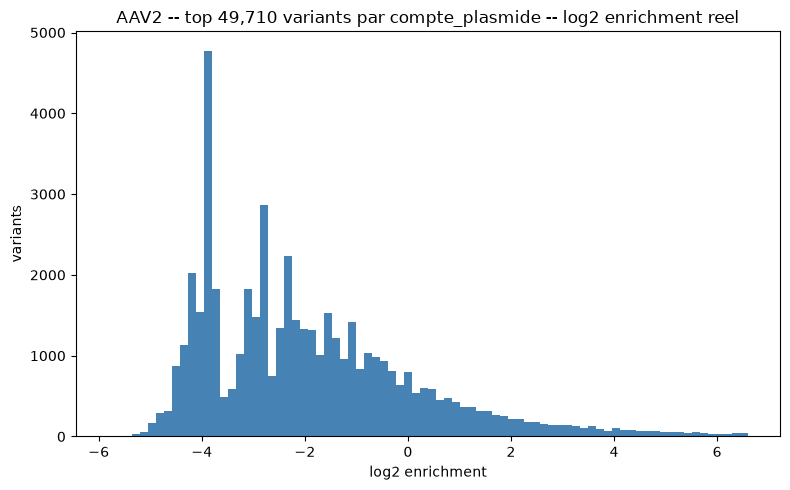

etendue : [-5.83, 6.60]  (vs [-5.83,+19.24] sur le dataset complet avant filtre RATIO_MAX -- la contamination extreme est absente de cette population)


In [9]:
y_viab = df[viab_col].to_numpy(np.float64)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_viab, bins=80, color="steelblue")
ax.set(title=f"AAV2 -- top {d0:,} variants par compte_plasmide -- log2 enrichment reel",
       xlabel="log2 enrichment", ylabel="variants")
plt.tight_layout(); plt.show()
print(f"etendue : [{y_viab.min():.2f}, {y_viab.max():.2f}]  (vs [-5.83,+19.24] sur le dataset "
      f"complet avant filtre RATIO_MAX -- la contamination extreme est absente de cette population)")

## 3. Regression de Potts sur cette population

Meme recette que `AAV2_viab_sorting.ipynb` (`RegressionV1.fit_weights_potts_from_data`, poids
inverse-variance `eps=0.5`). Split **80/20** ici (pas 50/50 comme d'habitude) : avec seulement
~9 900 lignes pour 8 541 features, un split 50/50 laisserait le fit sous n=p -- 80/20 garde un peu
plus de marge (~7 950 lignes de fit), meme si ca reste une regularisation forte quel que soit le
split.

In [10]:
import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson
from sklearn.model_selection import train_test_split

lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(d0, 7)

p_arr = df["compte_plasmide"].to_numpy(np.float64)
v_arr = df["compte_virus"].to_numpy(np.float64)
w_arr = 1.0 / (1.0 / (v_arr + 0.5) + 1.0 / (p_arr + 0.5))

fit_i, eval_i = train_test_split(np.arange(d0), test_size=0.2, random_state=0)
print(f"n_fit={len(fit_i):,}  n_eval={len(eval_i):,}  (8541 features Potts)")


def score_FJ(seq, F, J):
    F, J = np.asarray(F, np.float64), np.asarray(J, np.float64)
    s = F[seq, np.arange(7)].sum(axis=1)
    for i in range(7):
        for j in range(i + 1, 7):
            s = s + J[i, j, seq[:, i], seq[:, j]]
    return s


LAMBDAS = np.logspace(-2, 6, 25)
F_cv, J_cv, rank_cv, info_cv = R.fit_weights_potts_from_data(
    seq_matrix[fit_i], y_viab[fit_i], sample_weight=w_arr[fit_i],
    lambdas_grid=LAMBDAS, k_folds=3, seed=0, verbose=False, lam=None)
r_cv = pearson(y_viab[eval_i], score_FJ(seq_matrix[eval_i], F_cv, J_cv))
print(f"CV : lambda={info_cv['lam']:.3g}  rank={rank_cv}/8541  held-out r={r_cv:+.3f}")

F_unreg, J_unreg, rank_unreg, _ = R.fit_weights_potts_from_data(
    seq_matrix[fit_i], y_viab[fit_i], sample_weight=w_arr[fit_i], lam=0.0, verbose=False)
r_unreg = pearson(y_viab[eval_i], score_FJ(seq_matrix[eval_i], F_unreg, J_unreg))
print(f"lam=0 : rank={rank_unreg}/8541  held-out r={r_unreg:+.3f}")

USE_CV = r_cv >= r_unreg
F_viab, J_viab = (np.asarray(F_cv), np.asarray(J_cv)) if USE_CV else (np.asarray(F_unreg), np.asarray(J_unreg))
tag = "cv" if USE_CV else "unreg"
r_potts = r_cv if USE_CV else r_unreg
print(f"-> retenu : {tag}  (held-out r = {r_potts:+.3f})")

np.save(LIB / f"aav2_F_viab_potts_top10k_{tag}.npy", F_viab.astype(np.float32))
np.save(LIB / f"aav2_J_viab_potts_top10k_{tag}.npy", J_viab.astype(np.float32))
print(f"exporte lib/aav2_F_viab_potts_top10k_{tag}.npy / aav2_J_viab_potts_top10k_{tag}.npy")

n_fit=39,768  n_eval=9,942  (8541 features Potts)


CV : lambda=464  rank=7709/8541  held-out r=+0.252
lam=0 : rank=7709/8541  held-out r=+0.180
-> retenu : cv  (held-out r = +0.252)
exporte lib/aav2_F_viab_potts_top10k_cv.npy / aav2_J_viab_potts_top10k_cv.npy


## 4. Simulation `ProtocolV3` -- phase viabilite avec ces poids

`lambda0` calibre sur le vrai `compte_plasmide` de chaque variant (comme
`AAV2_viab_fitting_protocol.ipynb`), `D` recalibre sur le ratio reads/variant de CETTE population
(23.5 plasmide / 28.2 virus -- beaucoup plus equilibre que sur la population complete, la
contamination retiree en section 1 expliquait l'essentiel de l'asymetrie observee ailleurs).
`F_sel=J_sel=0` (phase selectivite non modelisee).

In [11]:
import jax, jax.numpy as jnp
from sequence_classesV1 import ProtocolV3, message as scv_msg
print("sequence_classesV1:", scv_msg, "| JAX:", jax.default_backend(), jax.devices())

EPS = 0.5
RHO        = 1e-3
MU         = 50
T_VIAB     = 1.0 / np.log(2)
NOISE_VIAB = 0.5
D          = 25e5    # <-- ~250 reads/variant, encadre par 23.5 (plasmide) / 28.2 (virus) reels
DILUTION   = 1e5

N1 = MU * d0 / RHO
lambda0_init = p_arr * DILUTION
N0 = float(lambda0_init.sum())
sequences = jnp.asarray(seq_matrix)

print(f"d0={d0:,}  D={D:.0e}  D/d0={D / d0:.1f} reads/variant  N1={N1:.2e}  N0={N0:.2e}")

F_sel = jnp.zeros_like(jnp.asarray(F_viab))
J_sel = jnp.zeros_like(jnp.asarray(J_viab))


def simulate_round(seed):
    p = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0, N1=N1, dilution_factor=DILUTION,
                   sequences=sequences, D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
                   noise_viab=NOISE_VIAB, noise_sel=0.5, T_viab=T_VIAB, T_sel=1.0,
                   multinomialNGS=True, rho=RHO)
    p.lambda0 = jnp.asarray(lambda0_init)
    bio, ngs = p.loop_DE()
    l0p, l2p, l3p = (np.asarray(a, np.float64) for a in ngs)
    sim_viab = np.log2((l2p + EPS) / (l0p + EPS))
    return dict(p=p, l0p=l0p, l2p=l2p, sim_viab=sim_viab)


sims = [simulate_round(s) for s in (0, 1, 2)]
for k, s in enumerate(sims):
    print(f"  rep{k}: sim_viab fini {np.isfinite(s['sim_viab']).mean():.2%}  "
          f"(l2p>0 : {(s['l2p'] > 0).mean():.2%})")

sequence_classesV1: file 2.1 | JAX: gpu [CudaDevice(id=0)]
d0=49,710  D=2e+06  D/d0=50.3 reads/variant  N1=2.49e+09  N0=8.40e+10


  rep0: sim_viab fini 100.00%  (l2p>0 : 88.61%)
  rep1: sim_viab fini 100.00%  (l2p>0 : 88.62%)
  rep2: sim_viab fini 100.00%  (l2p>0 : 88.61%)


r(sim_viab, reel viab) = +0.218   (n=49,710)


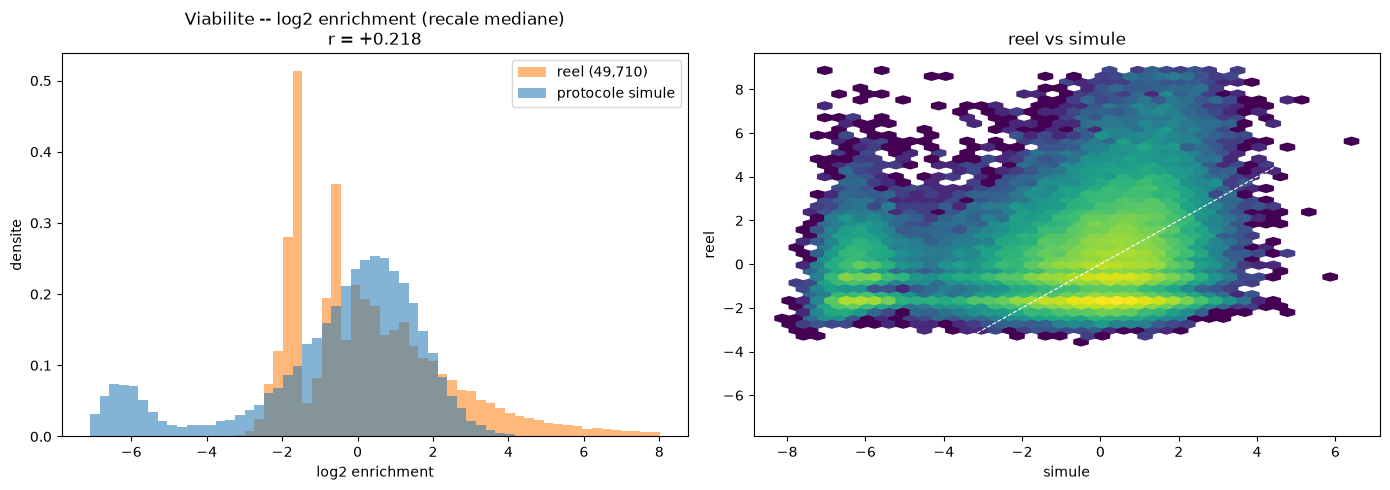

accord replicat-replicat (simule) :
  rep0 vs rep1 : +0.342
  rep0 vs rep2 : +0.335
  rep1 vs rep2 : +0.337


In [12]:
def center(x):
    x = np.asarray(x, np.float64)
    return x - np.median(x[np.isfinite(x)])

sim_viab = sims[0]["sim_viab"]
rv, sv = center(y_viab), center(sim_viab)
mfin = np.isfinite(rv) & np.isfinite(sv)
r_protocol = pearson(rv[mfin], sv[mfin])
print(f"r(sim_viab, reel viab) = {r_protocol:+.3f}   (n={mfin.sum():,})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lo, hi = np.percentile(np.concatenate([rv[mfin], sv[mfin]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 60)
axes[0].hist(rv[mfin], bins=bins, density=True, alpha=0.55, color="tab:orange", label=f"reel ({mfin.sum():,})")
axes[0].hist(sv[mfin], bins=bins, density=True, alpha=0.55, color="tab:blue", label="protocole simule")
axes[0].set(title=f"Viabilite -- log2 enrichment (recale mediane)\nr = {r_protocol:+.3f}",
            xlabel="log2 enrichment", ylabel="densite"); axes[0].legend()
axes[1].hexbin(sv[mfin], rv[mfin], gridsize=40, bins="log", cmap="viridis", mincnt=1)
d = [max(sv[mfin].min(), lo), min(sv[mfin].max(), hi)]
axes[1].plot(d, d, "w--", lw=0.8)
axes[1].set(title="reel vs simule", xlabel="simule", ylabel="reel")
plt.tight_layout(); plt.show()

print("accord replicat-replicat (simule) :")
for i, j in [(0, 1), (0, 2), (1, 2)]:
    a, b = center(sims[i]["sim_viab"]), center(sims[j]["sim_viab"])
    mm = np.isfinite(a) & np.isfinite(b)
    print(f"  rep{i} vs rep{j} : {pearson(a[mm], b[mm]):+.3f}")

## 5. `ShallowProfileMLP` sur la meme population

Meme archi/boucle que `AAV2_viab_profile_model.ipynb` (reprise verbatim des notebooks AAV5).
Meme split 80/20 que la regression de Potts (section 3), pour comparer les 3 methodes sur
exactement les memes lignes de fit/eval.

train=33,803  val=5,965  held-out=9,942


-> 23 epochs, held-out r=+0.274


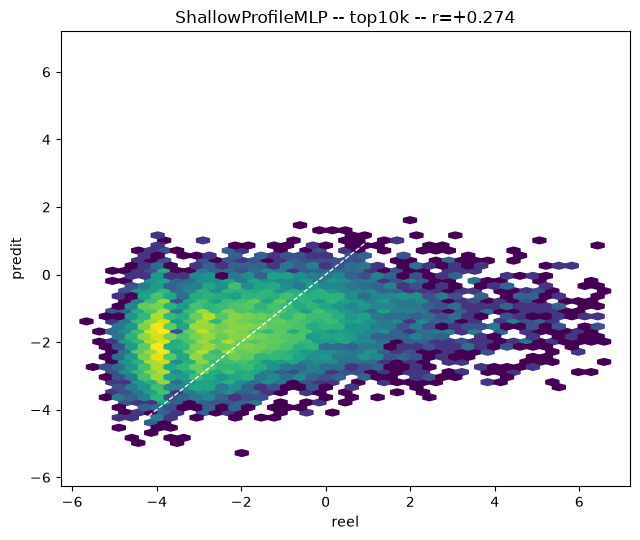

In [13]:
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm


class ShallowProfileMLP(nnx.Module):
    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, *, train: bool, rngs: Optional[nnx.Rngs] = None):
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)
        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)
        return self.linear3(x).squeeze(-1)


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    return jnp.mean((model(x, train=False) - y) ** 2)


@nnx.jit
def predict_step(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def train_mlp(model_cls, model_kwargs, X_train, y_train, X_val, y_val,
              epochs=150, batch_size=256, peak_lr=1e-3, final_lr=1e-5,
              weight_decay=0, patience=8, seed=0):
    rngs  = nnx.Rngs(seed)
    model = model_cls(rngs=rngs, **model_kwargs)
    n_train = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps = steps_per_epoch * epochs
    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr, warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9), end_value=final_lr)
    optimizer = nnx.Optimizer(model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param)
    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val, y_val = jnp.asarray(X_val), jnp.asarray(y_val)
    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}
    for epoch in tqdm(range(epochs), desc="  epochs", leave=False):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)
        (model, optimizer, rngs), step_losses = train_epoch_scan((model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx])
        val_loss = float(eval_step(model, X_val, y_val))
        history["train_loss"].append(float(jnp.mean(step_losses)))
        history["val_loss"].append(val_loss)
        if val_loss < best_val - 1e-5:
            best_val, bad_epochs, best_state = val_loss, 0, nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break
    nnx.update(model, best_state)
    return model, history


oh = lambda idx: np.eye(20, dtype=np.float32)[seq_matrix[idx]].reshape(len(idx), -1)
X_fit, y_fit = oh(fit_i), y_viab[fit_i]
X_eval, y_eval = oh(eval_i), y_viab[eval_i]
Xtr, ytr, Xva, yva = split_train_val(X_fit, y_fit, val_frac=0.15, seed=0)
print(f"train={len(Xtr):,}  val={len(Xva):,}  held-out={len(X_eval):,}")

mlp, hist = train_mlp(ShallowProfileMLP, dict(input_dim=7 * 20), Xtr, ytr, Xva, yva, seed=0)
pred_mlp = np.asarray(predict_step(mlp, jnp.asarray(X_eval)))
r_mlp = pearson(y_eval, pred_mlp)
print(f"-> {len(hist['train_loss'])} epochs, held-out r={r_mlp:+.3f}")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.hexbin(y_eval, pred_mlp, gridsize=40, bins="log", cmap="viridis", mincnt=1)
lo, hi = min(y_eval.min(), pred_mlp.min()), max(y_eval.max(), pred_mlp.max())
ax.plot([lo, hi], [lo, hi], "w--", lw=0.9)
ax.set(title=f"ShallowProfileMLP -- top10k -- r={r_mlp:+.3f}", xlabel="reel", ylabel="predit")
plt.tight_layout(); plt.show()

## 6. Comparaison des 3 methodes

In [14]:
comparison = pd.DataFrame([
    {"methode": "Potts (regression, lineaire)", "held-out r": round(r_potts, 3)},
    {"methode": "ProtocolV3 (mecaniste, poids Potts ci-dessus)", "held-out r": round(r_protocol, 3)},
    {"methode": "ShallowProfileMLP", "held-out r": round(r_mlp, 3)},
])
comparison

,methode,held-out r
0,"Potts (regression, lineaire)",0.252
1,"ProtocolV3 (mecaniste, poids Potts ci-dessus)",0.218
2,ShallowProfileMLP,0.274


## 7. Notes

- Population : top 10 000 variants par `compte_plasmide` sur `AAV2_organoides.csv`, moins 57 lignes
  a `ratio virus/plasmide > 100` (contamination residuelle) -> 9 943 variants, `compte_plasmide`
  dans [19, 61].
- **Pas de dithering** (feedback utilisateur -- "ajoute juste du bruit") : les histogrammes/metriques
  ci-dessus sont calcules directement sur les comptages/ratios bruts.
- Regression de Potts et MLP : split **80/20** (pas 50/50) pour laisser plus de lignes au fit vu la
  taille reduite de cette population face aux 8541 features du modele Potts.
- `D=2.5e5` (`ProtocolV3`) calibre sur le ratio reads/variant reel de CETTE population (23.5
  plasmide / 28.2 virus) -- differe du `D=5e5` utilise dans `AAV2_viab_fitting_protocol.ipynb` (qui
  travaillait sur une population bien plus large et moins concentree).
- `rho`/`mu`/`T_viab`/`noise_viab`/`dilution_factor` repris tels quels du point de fonctionnement
  deja etabli -- non recalibres pour cette population precise.